# Diputrax V12 — Robustez de la periodización: agrupaciones alternativas de legislaturas

**Naturaleza de este cuaderno.** Este notebook es una **adición** a `diputraxv10.ipynb` (cuaderno principal de la tesis) y `diputraxv11.ipynb` (respuestas a observaciones); **no reemplaza ni modifica** ningún target, modelo ni conclusión de aquellos. Su objeto es responder una pregunta de robustez metodológica que la tesis asume pero no somete a prueba directa:

> **¿Es la división en 4 eras políticas (PRI / PAN / Transición / Morena) la agrupación de legislaturas que mejor sirve a los modelos, o una partición distinta —por ejemplo, dos eras con corte en 2018— rendiría igual o mejor?**

**Estructura.** La sección 1 presenta la **argumentación** de por qué la periodización en 4 eras funciona (fundamento sustantivo, empírico y estadístico). Las secciones 2–4 replican la infraestructura de v10 y definen **seis esquemas alternativos de agrupación** junto con un protocolo de evaluación **comparable entre esquemas** (predicciones *out-of-fold* evaluadas sobre estratos fijos). La **sección 5** justifica por qué los métodos de análisis empleados (validación cruzada *out-of-fold*, evaluación estratificada, AUC/MAE y similitud de coeficientes) son los adecuados para la pregunta. Las secciones 6–7 reportan el desempeño de los modelos de regresión (LR L1+SFM —el modelo principal de la tesis—, LR L1 completo y GLM Poisson) bajo cada esquema. La sección 8 analiza la heterogeneidad de coeficientes entre legislaturas, y la sección 9 concluye.

**Ejecución secuencial.** El cuaderno replica de forma idéntica y autocontenida el pipeline de `diputraxv10` (imputación MICE → *feature engineering* → `LogisticRegression` L1 + `SelectFromModel`, CV estratificada *k*=5, `random_state=42` en todas las particiones). Corre de principio a fin sin depender de v10 ni v11 en tiempo de ejecución.

**Nota de entorno.** Solo requiere `scikit-learn`, `pandas`, `numpy`, `matplotlib` y `seaborn`; no usa SHAP, XGBoost ni PyMC, porque la pregunta de este cuaderno es de **comparación de esquemas de agrupación**, no de interpretación de features ni de inferencia bayesiana (ambas ya cubiertas en v10/v11).

# 1. Argumentación — ¿Por qué funciona la división en 4 eras?

La periodización de la tesis agrupa las diez legislaturas (LVII–LXVI, 1997–presente) en cuatro eras: `ERA_1_PRI` (57–59), `ERA_2_PAN` (60–62), `ERA_3_TRANS` (63–65) y `ERA_4_MORENA` (66). Esa división **funciona** —en el sentido de que produce modelos válidos, interpretables y comparables— por tres razones que operan en niveles distintos y se refuerzan entre sí.

## 1.1 Fundamento sustantivo: las eras son configuraciones de poder, no décadas

La asignación de comisiones en la Cámara de Diputados no es un proceso administrativo neutro: la negocia la **JUCOPO** (Junta de Coordinación Política) y la controla, en la práctica, la coalición dominante de cada ciclo político. Las cuatro eras corresponden a cuatro configuraciones distintas de ese poder de asignación:

| Era | Legislaturas | Configuración de poder |
|---|---|---|
| `ERA_1` | 57–59 (1997–2006) | Hegemonía priista en retirada: el PRI pierde la mayoría absoluta en 1997 pero conserva la maquinaria de asignación y sus criterios corporativos (trayectoria administrativa, cuadros de gobierno). |
| `ERA_2` | 60–62 (2006–2015) | Bipartidismo con presidencias panistas: el PAN hereda la lógica de asignación pero la reorienta; el reparto sigue siendo predecible desde el perfil burocrático. |
| `ERA_3` | 63–65 (2015–2024) | Fragmentación multipartidista: nuevos partidos (Morena, MC), candidaturas independientes, reelección legislativa (desde 2018) y paridad constitucional (2019). Los criterios de asignación se pluralizan y se vuelven menos legibles desde el perfil biográfico. |
| `ERA_4` | 66 (2024–) | Dominio de Morena con mayoría calificada: recentralización del reparto, pero con un criterio nuevo —carrera *parlamentaria* (cargos legislativos previos, senaduría, posgrado) en lugar de carrera *administrativa*. |

El punto clave es que la unidad natural de cambio del mecanismo de asignación **no es la legislatura individual** (cada tres años no se reinventa la lógica de la JUCOPO) **ni el sexenio presidencial** (la Cámara tiene ciclos propios), sino el **ciclo de coalición dominante**. Las 4 eras son la operacionalización de ese ciclo.

## 1.2 Fundamento empírico: la evidencia de v10 muestra rupturas en las fronteras de era

Tres resultados del cuaderno principal (`diputraxv10`) confirman que las fronteras de era coinciden con cambios reales del mecanismo:

1. **Validación temporal *rolling forward*** (§8.2 de v10): un modelo LR L1+SFM entrenado en la era *k* y aplicado a la era *k*+1 pierde capacidad predictiva en cada frontera —AUC nodal 0.711 (E1→E2), **0.652 (E2→E3, la ruptura más profunda)**, 0.712 (E3→E4)— frente a AUC dentro de era de 0.696–0.728. Si las eras fueran una partición arbitraria, la transferencia entre eras adyacentes no se degradaría de forma sistemática.

2. **Cambio de perfil, no solo de nivel** (§5–9 de v10): las importancias SHAP muestran que **qué** variables predicen cambia entre eras: la trayectoria administrativa (presidencia municipal, direcciones generales) domina en ERA 1–2 y cede ante la carrera legislativa en ERA 4 (hallazgo H5); `sexo_bin` es predictor estructural en ERA 1–2 y desaparece en ERA 4 (H7). Un modelo único agrupado no puede representar esos cambios de signo y jerarquía salvo con interacciones explícitas era×feature —que es exactamente lo que la partición por eras implementa de forma no paramétrica.

3. **Las tasas base de los targets se mueven con las eras**: la proporción de diputados con comisión nodal sube monotónicamente de 0.32 (ERA 1) a 0.55 (ERA 4), y la de lastre cae de ~0.50 a 0.39 en ERA 4. Agrupar eras heterogéneas mezcla poblaciones con prevalencias distintas y contamina tanto la calibración como la interpretación de los coeficientes.

## 1.3 Fundamento estadístico: el equilibrio n-por-grupo vs. homogeneidad interna

Toda partición temporal enfrenta el mismo dilema: grupos más finos son más homogéneos pero tienen menos datos; grupos más gruesos tienen más datos pero mezclan regímenes. La división en 4 eras se sitúa en un punto defendible de ese intercambio:

- **n ≈ 1,500 por era** (500 en ERA 4, limitación reconocida en §10.2 de v10): suficiente para estimar un AUC con IC95 de ±0.027–0.029 (±0.048 en ERA 4, análisis de potencia Hanley–McNeil).
- **Homogeneidad interna verificable**: dentro de cada era las tres legislaturas comparten coalición dominante, reglas de paridad y composición partidista aproximada (la sección 8 de este cuaderno lo cuantifica con la similitud de coeficientes entre legislaturas).
- **Interpretabilidad como condición de validez**: la tesis compara perfiles *entre* eras (H4, H5, H7). Esa comparación exige que cada era tenga su propio vector de coeficientes. Una partición más gruesa la imposibilita; una más fina (por legislatura) triplica la varianza de los coeficientes sin añadir contenido sustantivo.

## 1.4 El criterio falsable — y el experimento de este cuaderno

La argumentación anterior es contrastable. Si la periodización en 4 eras es la correcta, deben cumplirse dos predicciones:

- **P1 (contra agrupaciones más gruesas):** los modelos por era deben rendir **al menos igual** que un modelo único (pooled) o que dos modelos con corte en 2018, cuando todos se evalúan sobre los mismos estratos fijos. Si un corte único en 2018 bastara, la distinción PRI/PAN y la separación TRANS/MORENA serían ornamentales.
- **P2 (contra agrupaciones más finas):** los modelos por legislatura (n≈500) **no** deben superar sistemáticamente a los modelos por era; si lo hicieran, la era estaría mezclando legislaturas heterogéneas y la ganancia por homogeneidad superaría el costo muestral.

Las secciones 3–8 implementan exactamente esa prueba: seis esquemas de agrupación, mismos features, mismo modelo de regresión, misma semilla, y evaluación *out-of-fold* sobre estratos idénticos. La sección 9 emite el veredicto.

# 2. Infraestructura replicada de diputraxv10

Réplica **verbatim** del pipeline de v10 (mismas constantes de era, misma imputación MICE, mismo *feature engineering*, mismas *model factories*), en el formato compacto de las celdas 2–7 de `diputraxv11.ipynb`.

In [1]:
import warnings, io, os
warnings.filterwarnings("ignore")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # evita warning wmic de joblib/loky en Windows 11

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score, cross_val_predict,
)
from sklearn.metrics import roc_auc_score, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)
print("Imports OK")

Imports OK


In [2]:
# --- Constantes idénticas a v10 (celda 70) ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET = PROJECT_ROOT / "data" / "clean" / "diputados_20260421_205712.parquet"

ERA_MAP = {
    57: "ERA_1_PRI",  58: "ERA_1_PRI",  59: "ERA_1_PRI",
    60: "ERA_2_PAN",  61: "ERA_2_PAN",  62: "ERA_2_PAN",
    63: "ERA_3_TRANS", 64: "ERA_3_TRANS", 65: "ERA_3_TRANS",
    66: "ERA_4_MORENA",
}
ERA_ORDER = ["ERA_1_PRI", "ERA_2_PAN", "ERA_3_TRANS", "ERA_4_MORENA"]
ERA_LABELS = {
    "ERA_1_PRI":    "ERA 1 — PRI (57-59)",
    "ERA_2_PAN":    "ERA 2 — PAN (60-62)",
    "ERA_3_TRANS":  "ERA 3 — Transicion (63-65)",
    "ERA_4_MORENA": "ERA 4 — Morena (66)",
}
ERA_COLORS = {
    "ERA_1_PRI": "#c0392b", "ERA_2_PAN": "#2980b9",
    "ERA_3_TRANS": "#8e44ad", "ERA_4_MORENA": "#27ae60",
}
TOP_PARTIDOS = ["PRI", "PAN", "MORENA", "PRD", "PVEM", "PT", "MC"]
LEGIS = list(range(57, 67))

raw = pd.read_parquet(PARQUET)
print(f"Shape: {raw.shape}")

Shape: (5000, 79)


In [3]:
# --- MICE idéntico a v10 (celda 74) ---
_MICE_COND_VARS = [
    'legislatura_num', 'n_cargos_legislativos_prev',
    'fue_diputado_local', 'fue_diputado_federal', 'fue_senador',
    'n_trayectoria_legislativa', 'n_trayectoria_admin', 'nivel_cargo_max',
    'fue_presidente_mun', 'fue_secretario_cargo', 'fue_director_general',
    'fue_subsecretario', 'admin_en_gobierno_fed', 'admin_en_gobierno_est',
    'admin_en_gobierno_mun', 'edad_al_tomar_cargo',
]
_mice_cols = [c for c in _MICE_COND_VARS if c in raw.columns]
_mice_imputer = IterativeImputer(max_iter=10, random_state=42,
                                 initial_strategy='mean', skip_complete=True)
_mice_df = pd.DataFrame(_mice_imputer.fit_transform(raw[_mice_cols].copy()),
                        columns=_mice_cols, index=raw.index)

raw['edad_missing'] = raw['edad_al_tomar_cargo'].isna().astype(int)
raw['edad_imp'] = np.where(
    raw['edad_al_tomar_cargo'].isna(),
    _mice_df['edad_al_tomar_cargo'].clip(18, 90),
    raw['edad_al_tomar_cargo'],
)
print(f"MICE OK — N imputados: {int(raw['edad_missing'].sum())}, "
      f"media edad_imp: {raw['edad_imp'].mean():.2f}")

MICE OK — N imputados: 510, media edad_imp: 45.98


In [4]:
# --- Feature engineering idéntico a v10 (celda 75) ---
df = raw.copy()
df["era"] = df["legislatura_num"].map(ERA_MAP)

# Targets ORIGINALES de la tesis (idénticos a v10, intactos)
df["nodal_bin"]  = (df["n_comisiones_nodales"] >= 1).astype(int)
df["lastre_bin"] = (df["n_comisiones_lastre"]  >= 1).astype(int)

REGION_MAP = {
    "CDMX": "CDMX",
    **dict.fromkeys(["MEX","HGO","MOR","PUE","TLAX","QRO","GTO","AGS"], "CENTRO"),
    **dict.fromkeys(["VER","OAX","CHIS","TAB","GRO","CAM","YUC","QROO"], "SUR"),
    **dict.fromkeys(["NL","TAMPS","COAH","CHIH","SON","BC","BCS","SIN",
                     "DGO","ZAC","SLP","NAY"], "NORTE"),
    **dict.fromkeys(["JAL","COL","MICH"], "OCCIDENTE"),
    "DESCONOCIDO": "RP",
}
df["region"]      = df["entidad_codigo"].map(REGION_MAP).fillna("CENTRO")
df["partido_cat"] = df["partido"].where(df["partido"].isin(TOP_PARTIDOS), "OTRO")
df["univ_elite"]  = df[["acad_unam","acad_itam","acad_ibero","acad_itesm"]].max(axis=1)
df["sexo_bin"]    = (df["sexo"] == "M").astype(int)

_p    = pd.get_dummies(df["partido_cat"],    prefix="p")
_reg  = pd.get_dummies(df["region"],         prefix="reg")
_area = pd.get_dummies(df["area_formacion"], prefix="area")
df_enc = pd.concat([df, _p, _reg, _area], axis=1)

print("Feature engineering OK")
print("\nTasas de los targets por era:")
display(df.groupby("era")[["nodal_bin","lastre_bin","n_comisiones_tematicas"]]
          .mean().reindex(ERA_ORDER).round(3))

Feature engineering OK

Tasas de los targets por era:


,nodal_bin,lastre_bin,n_comisiones_tematicas
era,,,
ERA_1_PRI,0.322,0.421,1.531
ERA_2_PAN,0.407,0.459,1.927
ERA_3_TRANS,0.495,0.499,2.146
ERA_4_MORENA,0.554,0.392,1.868


**Lectura — tasas base de los targets por era.** La tabla muestra la prevalencia de cada target dentro de cada era. La proporción de diputados con **comisión nodal** sube de forma monótona (0.322 → 0.407 → 0.495 → 0.554): acceder a una comisión estratégica se ha vuelto progresivamente más común. El **lastre** se mantiene en torno a ~0.42–0.50 y cae a 0.392 en ERA 4 (Morena reparte menos comisiones de bajo perfil). Las **temáticas** (conteo medio) alcanzan su máximo en ERA 3 (2.146).

*Relevancia para el análisis.* Estas tasas base tan distintas son la primera evidencia de que las eras son **poblaciones heterogéneas**, no cortes arbitrarios del tiempo. También son la razón técnica por la que la evaluación posterior debe estratificarse: un modelo agrupado podría inflar su AUC solo por explotar estas diferencias de prevalencia entre periodos (§4, §5.2), sin aprender nada del diputado individual.


In [5]:
# --- Espacio de features idéntico a v10 (celda 76) ---
NUMERIC_FEATS = [
    "sexo_bin", "edad_imp", "edad_missing",
    "mayoria_relativa", "es_partido_mayoria", "legislatura_num",
    "grado_estudios_ord", "tiene_posgrado", "tiene_doctorado",
    "estudios_en_extranjero", "univ_publica", "univ_privada",  # AC1(v0): univ_extranjera eliminada — duplicado exacto (r=1.0)
    "univ_elite",
    # AC1(v0): n_cargos_legislativos_prev eliminada — = fue_diputado_local+fue_diputado_federal+fue_senador (combinacion lineal exacta)
    "fue_diputado_local",
    "fue_diputado_federal", "fue_senador", "n_trayectoria_legislativa",
    "n_trayectoria_admin", "nivel_cargo_max",
    "fue_presidente_mun", "fue_presidente_org", "fue_director_general",
    "fue_secretario_cargo", "fue_subsecretario", "fue_director",
    "fue_coordinador", "fue_delegado", "fue_asesor", "fue_regidor", "fue_sindico",
    "admin_en_partido", "admin_en_sindicato", "admin_en_universidad",
    "admin_en_gobierno_fed", "admin_en_gobierno_est", "admin_en_gobierno_mun",
    "n_trayectoria_politica", "tiene_exp_juvenil",
    "lider_juvenil_partido", "lider_juvenil_gobierno", "miembro_org_juvenil",
    "nivel_liderazgo_juvenil",
    "n_trayectoria_empresarial", "n_investigacion_docencia", "n_organos_gobierno",
]
_AREA_KEEP = ["area_Derecho", "area_Ciencias Políticas y Sociales",
              "area_Económico-Financiera"]
DUMMY_FEATS = list(_p.columns) + list(_reg.columns) + \
              [c for c in _AREA_KEEP if c in df_enc.columns]
FEAT_COLS = NUMERIC_FEATS + DUMMY_FEATS
print(f"Features totales: {len(FEAT_COLS)}  "
      f"(numéricas={len(NUMERIC_FEATS)}, dummies={len(DUMMY_FEATS)})")

Features totales: 64  (numéricas=47, dummies=17)


## Acciones correctivas (derivadas de diputraxv0)

Se propagan a este cuaderno las acciones correctivas aplicadas en diputraxv10, derivadas del diagnóstico de supuestos de `diputraxv0` (§8 y §12):

- **AC1 — Consolidación de features redundantes.** Se elimina `univ_extranjera` (duplicado exacto de `estudios_en_extranjero`, r=1.0) y `n_cargos_legislativos_prev` (suma exacta de `fue_diputado_local + fue_diputado_federal + fue_senador`, ya incluidos). Son redundancias *dentro del espacio-columna*: el AUC/MAE es invariante a su eliminación; solo se depura la atribución SHAP y los VIF.
- **AC2 — Validación sin fuga por reelección.** Se añaden `get_groups()` (por `diputado_id`) y `cv_auc_grouped` / `cv_mae_grouped` (`StratifiedGroupKFold` / `GroupKFold`) para estimar el desempeño sin que un mismo diputado reelecto quede en train y test del mismo fold.

**No aplica aquí:** AC1b (reindexado de `KEY_FEATS`) — v12 no define `KEY_FEATS`.

**Límite interpretativo (v0 §6, §8):** en eras de partido dominante `es_partido_mayoria` es casi colineal con la identidad partidista (VIF≈129 en ERA_4); su lectura debe ser asociativa, no causal.

In [6]:
# --- Model factories idénticas a v10 (celda 78) ---
_L1_PARAMS = dict(l1_ratio=1, solver='liblinear', C=0.1, max_iter=3000,
                  class_weight='balanced', random_state=42)

def lr_binary():
    "LR L1 (Lasso) completo — idéntico a v10."
    return Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(**_L1_PARAMS))])

def lr_l1_sfm():
    "scale -> SelectFromModel(L1) -> L1 — pipeline principal de v10 (Tabla 7)."
    return Pipeline([
        ("sc",  StandardScaler()),
        ("sfm", SelectFromModel(LogisticRegression(**_L1_PARAMS), threshold="mean")),
        ("lr",  LogisticRegression(**_L1_PARAMS)),
    ])

def lr_poisson():
    "GLM Poisson — idéntico a v10."
    return Pipeline([("sc", StandardScaler()),
                     ("pr", PoissonRegressor(alpha=1.0, max_iter=3000))])

def cv_auc(model, X, y, k=5):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

# Paleta categórica para los ESQUEMAS (orden fijo, validada CVD;
# las eras conservan ERA_COLORS de v10)
SCHEME_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
TXT = "#333333"
# -- AC2(v0): validacion sin fuga por reeleccion (agrupada por diputado_id) --
# get_groups usa diputado_id como clave para que un mismo diputado reelecto
# no caiga en train y test del mismo fold (fuga por reeleccion).
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold

def get_groups(era):
    mask = df_enc["era"] == era
    if "diputado_id" in df_enc.columns:
        return df_enc.loc[mask, "diputado_id"].reset_index(drop=True)
    return pd.Series(range(int(mask.sum())))

def cv_auc_grouped(model, X, y, groups, k=5):
    cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(model, X, y, groups=groups, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

def cv_mae_grouped(model, X, y, groups, k=5):
    cv = GroupKFold(n_splits=k)
    s = -cross_val_score(model, X, y, groups=groups, cv=cv, scoring="neg_mean_absolute_error")
    return s.mean(), s.std()

print("Infraestructura de modelado replicada de v10 — OK")

Infraestructura de modelado replicada de v10 — OK


# 3. Esquemas alternativos de agrupación

Seis esquemas que recorren todo el espectro de granularidad, del modelo único al modelo por legislatura. `S4_ERAS` es la periodización de la tesis (línea base). `S2_2018` es una alternativa que separa los gobiernos de Morena del resto del periodo democratico: **dos eras con corte en 2018** (LVII–LXIII antes de la elección de 2018; LXIV–LXVI después, con las mayorías de Morena).

| Esquema | Grupos | Racionalidad |
|---|---|---|
| `S1_POOLED` | 1 (57–66) | Hipótesis nula: el mecanismo de asignación es único y estable; máxima muestra (n=5,000). |
| `S2_2018` | 2 (57–63 / 64–66) | El parteaguas es la elección de 2018: antes/después de las mayorías de Morena. |
| `S3_FUSION34` | 3 (57–59 / 60–62 / 63–66) | Como la tesis, pero sin separar Morena de la Transición: pone a prueba si ERA 4 merece modelo propio. |
| `S4_ERAS` | 4 (57–59 / 60–62 / 63–65 / 66) | **Periodización de la tesis** (línea base). |
| `S5_PARES` | 5 (pares consecutivos) | Ventanas uniformes de 2 legislaturas, ciegas a la política: si rinden igual que S4, las fronteras sustantivas serían ornamentales. |
| `S6_LEGIS` | 10 (una por legislatura) | Máxima homogeneidad, mínima muestra (n≈500): pone a prueba P2. |

Todos los esquemas usan **el mismo espacio de 61 features, el mismo modelo (LR L1+SFM) y la misma semilla**; lo único que cambia es qué filas entran juntas al entrenamiento. Nótese que `legislatura_num` está en `FEAT_COLS` (igual que en v10): los esquemas gruesos pueden usarla para adaptarse parcialmente al tiempo, lo que hace la comparación *conservadora* a favor de los esquemas gruesos.

In [7]:
# --- Definición de esquemas: legislatura -> grupo ---
SCHEMES = {
    "S1_POOLED": {l: "TODAS_57_66" for l in LEGIS},
    "S2_2018":   {l: ("PRE_2018" if l <= 63 else "POST_2018") for l in LEGIS},
    "S3_FUSION34": {
        **{l: "G1_PRI_57_59" for l in (57, 58, 59)},
        **{l: "G2_PAN_60_62" for l in (60, 61, 62)},
        **{l: "G3_TRANSMOR_63_66" for l in (63, 64, 65, 66)},
    },
    "S4_ERAS": dict(ERA_MAP),
    "S5_PARES": {l: f"PAR_{57 + 2*((l-57)//2)}_{58 + 2*((l-57)//2)}" for l in LEGIS},
    "S6_LEGIS": {l: f"LEG_{l}" for l in LEGIS},
}
SCHEME_ORDER = list(SCHEMES.keys())
SCHEME_SHORT = {
    "S1_POOLED": "S1 — Pooled (1 grupo)",
    "S2_2018":   "S2 — Corte 2018 (2 grupos)",
    "S3_FUSION34": "S3 — Fusión T+M (3 grupos)",
    "S4_ERAS":   "S4 — 4 eras (tesis)",
    "S5_PARES":  "S5 — Pares uniformes (5)",
    "S6_LEGIS":  "S6 — Por legislatura (10)",
}

# Tabla de composición: n y tasas base por grupo de cada esquema
rows = []
for sch, mapping in SCHEMES.items():
    grp = df_enc["legislatura_num"].map(mapping)
    for g in pd.unique(grp):
        m = grp == g
        rows.append({
            "Esquema": sch, "Grupo": g, "n": int(m.sum()),
            "Tasa nodal": df_enc.loc[m, "nodal_bin"].mean(),
            "Tasa lastre": df_enc.loc[m, "lastre_bin"].mean(),
            "Media temáticas": df_enc.loc[m, "n_comisiones_tematicas"].mean(),
        })
df_schemes = pd.DataFrame(rows)
display(df_schemes.set_index(["Esquema", "Grupo"]).round(3))

n  Tasa nodal  Tasa lastre  Media temáticas
Esquema     Grupo                                                            
S1_POOLED   TODAS_57_66        5000       0.423        0.453            1.868
S2_2018     PRE_2018           3500       0.376        0.447            1.789
            POST_2018          1500       0.533        0.467            2.052
S3_FUSION34 G1_PRI_57_59       1500       0.322        0.421            1.531
            G3_TRANSMOR_63_66  2000       0.510        0.472            2.076
            G2_PAN_60_62       1500       0.407        0.459            1.927
S4_ERAS     ERA_1_PRI          1500       0.322        0.421            1.531
            ERA_3_TRANS        1500       0.495        0.499            2.146
            ERA_2_PAN          1500       0.407        0.459            1.927
            ERA_4_MORENA        500       0.554        0.392            1.868
S5_PARES    PAR_59_60          1000       0.373        0.443            1.753
            PAR_57_58          1000       0.307        0.398            1.430
            PAR_63_64          1000       0.454        0.483            2.083
            PAR_61_62          1000       0.414        0.479            2.004
            PAR_65_66          1000       0.566        0.461            2.070
S6_LEGIS    LEG_59              500       0.352        0.466            1.732
            LEG_58              500       0.334        0.432            1.522
            LEG_57              500       0.280        0.364            1.338
            LEG_63              500       0.442        0.488            2.150
            LEG_62              500       0.420        0.526            2.232
            LEG_64              500       0.466        0.478            2.016
            LEG_61              500       0.408        0.432            1.776
            LEG_66              500       0.554        0.392            1.868
            LEG_65              500       0.578        0.530            2.272
            LEG_60              500       0.394        0.420            1.774

**Lectura — composición de los esquemas.** La tabla despliega, para cada esquema, el tamaño muestral (`n`) y las tasas base de cada grupo. Recorre el espectro completo de granularidad: de **S1** (un solo grupo, n=5,000) a **S6** (un grupo por legislatura, n≈500). Nótese el cuello de botella muestral de la tesis: en **S4**, `ERA_4_MORENA` tiene solo **n=500** (una legislatura), frente a n=1,500 de las otras tres eras.

*Relevancia para el análisis.* La `n` por grupo gobierna directamente la **varianza de los coeficientes y del AUC**: grupos más finos son más homogéneos pero más ruidosos. Comparar esquemas es, en el fondo, comparar el intercambio **sesgo** (mezclar regímenes distintos) contra **varianza** (estimar con poca muestra) descrito en §1.3. Las tasas base por grupo también anticipan qué particiones funden poblaciones dispares —p. ej., `POST_2018` de S2 (n=1,500) promedia el final de la Transición con la mayoría calificada de Morena—, algo que la evaluación estratificada y la §8 pondrán a prueba.


# 4. Diseño de evaluación comparable entre esquemas

**El problema.** El AUC de validación cruzada *dentro de cada grupo* no es comparable entre esquemas: cambia la n, cambia la mezcla de poblaciones y, sobre todo, un modelo agrupado puede ganar AUC "gratis" al distinguir entre periodos con tasas base distintas (predecir que un diputado de la LXVI tiene comisión nodal es fácil si la tasa de la LXVI es 0.55 y la global 0.42, sin saber nada del diputado).

**El protocolo.** Para cada esquema:

1. Dentro de cada grupo se generan **predicciones *out-of-fold*** con `cross_val_predict` (StratifiedKFold *k*=5, `shuffle=True`, `random_state=42`) — cada diputado recibe una probabilidad predicha por un modelo que **nunca lo vio en entrenamiento**.
2. Al terminar, **los 5,000 diputados tienen una predicción OOF** bajo cada esquema.
3. Las métricas se calculan sobre **estratos fijos, idénticos para todos los esquemas**:
   - **AUC por estrato-era** (las 4 eras canónicas) y su **promedio ponderado por n** — métrica principal;
   - **AUC por estrato-legislatura** (10 estratos) y su promedio ponderado — métrica granular;
   - AUC global (se reporta pero se interpreta con cautela por el efecto de tasas base descrito arriba).

Evaluar dentro de estratos fijos elimina el crédito por tasas base entre periodos **para todos los esquemas por igual**: lo único que puede subir el AUC estratificado es ordenar mejor a los diputados *dentro* del mismo periodo. Es la comparación honesta entre agrupaciones.

# 5. Justificación metodológica — ¿por qué estos métodos son útiles y relevantes?

Antes de leer los resultados conviene explicitar por qué el instrumental de este cuaderno —validación cruzada *out-of-fold*, evaluación sobre estratos fijos, AUC y MAE, un *baseline* sin features, y la similitud coseno de coeficientes— es el adecuado para la pregunta planteada en §1.4. La pregunta no es "¿qué modelo predice mejor?" sino "**¿qué agrupación de legislaturas sirve mejor al análisis?**", y esa diferencia dicta cada elección metodológica.

## 5.1 Validación cruzada *out-of-fold* (OOF): honestidad predictiva

Ajustar un modelo y evaluarlo sobre las mismas filas premia el **sobreajuste**: con 61 features y grupos de n≈500, un modelo puede memorizar ruido y exhibir un AUC engañosamente alto. La validación cruzada *k*=5 rompe ese círculo —cada diputado recibe una predicción de un modelo que **nunca lo vio en entrenamiento**— de modo que el desempeño reportado estima la capacidad de **generalización**, no de memorización. Es relevante aquí porque los esquemas finos (S6, n≈500) son precisamente los más expuestos al sobreajuste: sin OOF, S6 parecería competitivo por una razón espuria. Fijar `shuffle=True, random_state=42` en todas las particiones garantiza que las diferencias entre esquemas provengan del **esquema**, no de un reparto de folds distinto.

## 5.2 Evaluación sobre estratos fijos: la única comparación honesta entre esquemas

El AUC calculado *dentro de cada grupo* no es comparable entre esquemas porque cada esquema define grupos distintos, con distinta n y —crítico— distinta **tasa base**. Un modelo agrupado puede subir su AUC "gratis" solo por distinguir periodos con prevalencias diferentes, sin aprender nada sobre el diputado individual (§4). Recomponer las predicciones OOF y evaluarlas siempre sobre **los mismos 4 estratos-era** (y los 10 estratos-legislatura) neutraliza ese crédito por tasas base **para todos los esquemas por igual**: lo único que puede mover el AUC estratificado es ordenar mejor a los diputados *dentro* de un mismo periodo. Sin este control, la comparación estaría sesgada a favor de los esquemas gruesos.

## 5.3 AUC para lo binario, MAE para el conteo: cada métrica a su escala

- **AUC (targets binarios `nodal`/`lastre`).** El AUC mide la probabilidad de que el modelo asigne mayor score a un positivo que a un negativo tomados al azar: 0.5 = azar, 1.0 = perfecto. Su virtud decisiva es que es **invariante a la tasa base**, por lo que estratos con prevalencias distintas (0.32 en ERA 1, 0.55 en ERA 4) son directamente comparables y no premia simplemente predecir la clase mayoritaria —esencial con clases desbalanceadas y con `class_weight='balanced'`.
- **MAE (conteo `n_comisiones_tematicas`).** Para un conteo, el error absoluto medio está **en las unidades del fenómeno** (comisiones): un MAE de 0.82 significa "erramos por ~0.82 comisiones en promedio". Es interpretable, comparable entre esquemas (misma escala, mismos estratos) y no sufre la distorsión de tasa base del AUC.

## 5.4 *Baseline* sin features: la vara del valor añadido

Una métrica en abstracto no dice si el modelo **aporta**. Por eso las temáticas se contrastan contra un *baseline* que predice la media del estrato-era **sin usar ninguna feature**. Si los modelos no baten esa media, el perfil biográfico es irrelevante para el target, con independencia del esquema. El *baseline* convierte una cifra de MAE en un juicio: cuánta señal hay realmente.

## 5.5 Similitud coseno de coeficientes: desempeño ≠ estructura

El AUC responde *cuánto* predice cada esquema, pero no *si corta donde de verdad cambia el mecanismo* de asignación. Un esquema puede predecir bien y aun así trazar fronteras en el lugar equivocado. Para esa pregunta estructural se ajusta una LR L1 **por legislatura** y se compara la dirección de sus vectores de coeficientes con la **similitud coseno** (1 = misma lógica de asignación, 0 = ortogonal). Si la periodización es sustantiva, la similitud debe ser mayor *dentro* de una era que *entre* eras (estructura de bloques). Esta métrica es relevante porque valida la periodización por su **contenido interpretativo** —el que sostiene los hallazgos H4/H5/H7 de la tesis—, no solo por su exactitud.

## 5.6 Regularización L1 + `SelectFromModel` y reproducibilidad

La penalización **L1 (Lasso)** lleva a cero los coeficientes irrelevantes: produce modelos parsimoniosos, estables con n pequeña y con coeficientes **comparables posición a posición** entre legislaturas (requisito de §5.5). `SelectFromModel` replica el pipeline principal de v10 (Tabla 7), de modo que la comparación de esquemas se hace sobre **exactamente el mismo modelo** que usa la tesis —no sobre un sustituto—, lo que hace las conclusiones trasladables. Mantener features, semilla y modelo constantes, variando **solo** qué filas entran juntas al entrenamiento, aísla el efecto de la agrupación: es un experimento controlado, no una comparación de modelos distintos.

**En conjunto**, estos métodos convierten la pregunta "¿son las 4 eras la mejor partición?" en una prueba falsable, comparable y reproducible: OOF elimina el optimismo, la estratificación elimina el crédito por tasas base, AUC/MAE miden en la escala correcta, el *baseline* fija la vara del valor añadido, y la similitud coseno separa desempeño de validez estructural.


In [8]:
# --- Motor de evaluación OOF ---
def oof_predict(scheme_map, target, factory, is_binary=True):
    "Predicciones out-of-fold para TODOS los diputados bajo un esquema."
    grp = df_enc["legislatura_num"].map(scheme_map)
    oof = pd.Series(np.nan, index=df_enc.index)
    for g in pd.unique(grp):
        m = (grp == g).values
        X = df_enc.loc[m, FEAT_COLS].astype(float)
        y = df_enc.loc[m, target].astype(float)
        if is_binary:
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            p = cross_val_predict(factory(), X, y, cv=cv,
                                  method="predict_proba")[:, 1]
        else:
            cv = KFold(n_splits=5, shuffle=True, random_state=42)
            p = cross_val_predict(factory(), X, y, cv=cv)
        oof.loc[m] = p
    return oof

def strat_auc(oof, target, strata):
    "AUC por estrato + promedio ponderado por n."
    out, ns = {}, {}
    for s in pd.unique(df_enc[strata]):
        m = df_enc[strata] == s
        y = df_enc.loc[m, target]
        if y.nunique() < 2:
            continue
        out[s] = roc_auc_score(y, oof[m])
        ns[s] = int(m.sum())
    w = sum(out[s] * ns[s] for s in out) / sum(ns.values())
    return out, w

def strat_mae(oof, target, strata):
    "MAE por estrato + promedio ponderado por n."
    out, ns = {}, {}
    for s in pd.unique(df_enc[strata]):
        m = df_enc[strata] == s
        out[s] = mean_absolute_error(df_enc.loc[m, target], oof[m])
        ns[s] = int(m.sum())
    w = sum(out[s] * ns[s] for s in out) / sum(ns.values())
    return out, w

df_enc["legis_str"] = df_enc["legislatura_num"].astype(int).astype(str)
print("Motor de evaluación OOF listo")

Motor de evaluación OOF listo


In [9]:
# --- Ejecución: OOF para nodal y lastre bajo los 6 esquemas ---
# Modelo principal: LR L1+SFM (Tabla 7 de v10). Robustez: LR L1 completo.
OOF = {}   # OOF[(esquema, target, modelo)] = Series
for sch in SCHEME_ORDER:
    for target in ["nodal_bin", "lastre_bin"]:
        OOF[(sch, target, "sfm")] = oof_predict(SCHEMES[sch], target, lr_l1_sfm)
        OOF[(sch, target, "l1")]  = oof_predict(SCHEMES[sch], target, lr_binary)
    print(f"  {sch}: OOF nodal + lastre listos (SFM y L1 full)")
print("OK")

  S1_POOLED: OOF nodal + lastre listos (SFM y L1 full)


  S2_2018: OOF nodal + lastre listos (SFM y L1 full)


  S3_FUSION34: OOF nodal + lastre listos (SFM y L1 full)


  S4_ERAS: OOF nodal + lastre listos (SFM y L1 full)


  S5_PARES: OOF nodal + lastre listos (SFM y L1 full)


  S6_LEGIS: OOF nodal + lastre listos (SFM y L1 full)
OK


In [10]:
# --- Tablas de resultados: AUC por estrato-era y ponderados ---
def build_results(target):
    rows = []
    for sch in SCHEME_ORDER:
        per_era, w_era = strat_auc(OOF[(sch, target, "sfm")], target, "era")
        _, w_leg = strat_auc(OOF[(sch, target, "sfm")], target, "legis_str")
        _, w_era_l1 = strat_auc(OOF[(sch, target, "l1")], target, "era")
        glob = roc_auc_score(df_enc[target], OOF[(sch, target, "sfm")])
        rows.append({
            "Esquema": SCHEME_SHORT[sch],
            **{ERA_LABELS[e].split(" — ")[0]: per_era.get(e, np.nan)
               for e in ERA_ORDER},
            "Pond. eras": w_era, "Pond. legis": w_leg,
            "Global": glob, "Pond. eras (L1 full)": w_era_l1,
        })
    return pd.DataFrame(rows).set_index("Esquema")

res_nodal  = build_results("nodal_bin")
res_lastre = build_results("lastre_bin")

print("NODAL — AUC out-of-fold por estrato-era (modelo LR L1+SFM)")
display(res_nodal.round(3))
print("\nLASTRE — AUC out-of-fold por estrato-era (modelo LR L1+SFM)")
display(res_lastre.round(3))

NODAL — AUC out-of-fold por estrato-era (modelo LR L1+SFM)


,ERA 1,ERA 2,ERA 3,ERA 4,Pond. eras,Pond. legis,Global,Pond. eras (L1 full)
Esquema,,,,,,,,
S1 — Pooled (1 grupo),0.735,0.721,0.703,0.684,0.716,0.714,0.730,0.717
S2 — Corte 2018 (2 grupos),0.736,0.723,0.682,0.679,0.710,0.714,0.718,0.711
S3 — Fusión T+M (3 grupos),0.728,0.717,0.690,0.673,0.708,0.706,0.708,0.709
S4 — 4 eras (tesis),0.728,0.717,0.694,0.626,0.705,0.702,0.706,0.706
S5 — Pares uniformes (5),0.710,0.703,0.681,0.678,0.696,0.697,0.695,0.698
S6 — Por legislatura (10),0.691,0.689,0.655,0.626,0.673,0.671,0.672,0.675



LASTRE — AUC out-of-fold por estrato-era (modelo LR L1+SFM)


,ERA 1,ERA 2,ERA 3,ERA 4,Pond. eras,Pond. legis,Global,Pond. eras (L1 full)
Esquema,,,,,,,,
S1 — Pooled (1 grupo),0.579,0.638,0.610,0.592,0.607,0.604,0.610,0.611
S2 — Corte 2018 (2 grupos),0.589,0.650,0.605,0.594,0.612,0.610,0.621,0.612
S3 — Fusión T+M (3 grupos),0.583,0.634,0.607,0.579,0.605,0.601,0.610,0.607
S4 — 4 eras (tesis),0.583,0.634,0.603,0.523,0.598,0.592,0.601,0.601
S5 — Pares uniformes (5),0.565,0.627,0.616,0.560,0.598,0.592,0.605,0.601
S6 — Por legislatura (10),0.573,0.612,0.610,0.523,0.591,0.588,0.592,0.591


**Lectura — AUC *out-of-fold* estratificado (métrica principal).** Cada fila es un esquema; las columnas ERA 1–4 son el AUC en cada estrato-era fijo, y **`Pond. eras`** es su promedio ponderado por n: la cifra-titular honesta de este cuaderno. Recordatorio de escala: AUC 0.5 = azar, 1.0 = discriminación perfecta; al ser **invariante a la tasa base**, es comparable entre estratos con prevalencias muy distintas (§5.3).

*Qué dicen los números.* En **nodal**, los esquemas se ordenan en una banda estrecha (0.673–0.716); todos empatan salvo el peor (S6, por legislatura). En **lastre**, los AUC son mucho más bajos (~0.59–0.61): el lastre es un target **intrínsecamente más difícil de predecir** desde el perfil biográfico. La columna **`Global`** aparece inflada respecto a `Pond. eras` (p. ej., S1: 0.730 vs. 0.716): esa brecha es exactamente el **crédito por tasas base** entre periodos que la estratificación elimina (§4), y por eso `Pond. eras` —no `Global`— es la métrica válida para comparar esquemas. La última columna (LR L1 completo, sin SFM) sirve de **robustez**: si el ordenamiento se conserva, no depende del selector de features. La síntesis de estas cuatro columnas está en §6.1.


In [11]:
# --- Referencia: AUC 5-fold DENTRO de cada grupo (vista naive, no comparable) ---
rows = []
for sch in SCHEME_ORDER:
    grp = df_enc["legislatura_num"].map(SCHEMES[sch])
    for g in pd.unique(grp):
        m = (grp == g).values
        X = df_enc.loc[m, FEAT_COLS].astype(float)
        rec = {"Esquema": SCHEME_SHORT[sch], "Grupo": g, "n": int(m.sum())}
        for target, lbl in [("nodal_bin", "AUC nodal"), ("lastre_bin", "AUC lastre")]:
            y = df_enc.loc[m, target].astype(float)
            mu, sd = cv_auc(lr_l1_sfm(), X, y)
            rec[lbl] = mu
            rec[f"± {lbl.split()[-1]}"] = sd
        rows.append(rec)
df_within = pd.DataFrame(rows).set_index(["Esquema", "Grupo"])
print("AUC 5-fold CV dentro de cada grupo (informativo; NO comparable entre esquemas")
print("por el efecto de tasas base — ver §4):")
display(df_within.round(3))

AUC 5-fold CV dentro de cada grupo (informativo; NO comparable entre esquemas
por el efecto de tasas base — ver §4):


n  AUC nodal  ± nodal  \
Esquema                    Grupo                                         
S1 — Pooled (1 grupo)      TODAS_57_66        5000      0.730    0.013   
S2 — Corte 2018 (2 grupos) PRE_2018           3500      0.732    0.024   
                           POST_2018          1500      0.689    0.031   
S3 — Fusión T+M (3 grupos) G1_PRI_57_59       1500      0.728    0.030   
                           G3_TRANSMOR_63_66  2000      0.689    0.017   
                           G2_PAN_60_62       1500      0.719    0.030   
S4 — 4 eras (tesis)        ERA_1_PRI          1500      0.728    0.030   
                           ERA_3_TRANS        1500      0.696    0.024   
                           ERA_2_PAN          1500      0.719    0.030   
                           ERA_4_MORENA        500      0.629    0.053   
S5 — Pares uniformes (5)   PAR_59_60          1000      0.690    0.028   
                           PAR_57_58          1000      0.721    0.026   
                           PAR_63_64          1000      0.692    0.026   
                           PAR_61_62          1000      0.715    0.038   
                           PAR_65_66          1000      0.673    0.046   
S6 — Por legislatura (10)  LEG_59              500      0.688    0.052   
                           LEG_58              500      0.641    0.094   
                           LEG_57              500      0.742    0.053   
                           LEG_63              500      0.688    0.038   
                           LEG_62              500      0.681    0.021   
                           LEG_64              500      0.673    0.047   
                           LEG_61              500      0.732    0.038   
                           LEG_66              500      0.629    0.053   
                           LEG_65              500      0.612    0.019   
                           LEG_60              500      0.647    0.048   

                                              AUC lastre  ± lastre  
Esquema                    Grupo                                    
S1 — Pooled (1 grupo)      TODAS_57_66             0.610     0.015  
S2 — Corte 2018 (2 grupos) PRE_2018                0.625     0.009  
                           POST_2018               0.607     0.024  
S3 — Fusión T+M (3 grupos) G1_PRI_57_59            0.583     0.015  
                           G3_TRANSMOR_63_66       0.609     0.020  
                           G2_PAN_60_62            0.634     0.032  
S4 — 4 eras (tesis)        ERA_1_PRI               0.583     0.015  
                           ERA_3_TRANS             0.601     0.026  
                           ERA_2_PAN               0.634     0.032  
                           ERA_4_MORENA            0.525     0.028  
S5 — Pares uniformes (5)   PAR_59_60               0.589     0.031  
                           PAR_57_58               0.560     0.026  
                           PAR_63_64               0.604     0.020  
                           PAR_61_62               0.638     0.024  
                           PAR_65_66               0.627     0.047  
S6 — Por legislatura (10)  LEG_59                  0.546     0.058  
                           LEG_58                  0.535     0.042  
                           LEG_57                  0.634     0.022  
                           LEG_63                  0.626     0.042  
                           LEG_62                  0.648     0.049  
                           LEG_64                  0.570     0.048  
                           LEG_61                  0.639     0.031  
                           LEG_66                  0.525     0.028  
                           LEG_65                  0.649     0.072  
                           LEG_60                  0.544     0.043

**Lectura — AUC dentro de grupo (vista *naive*, no comparable).** Esta tabla reporta el AUC de validación cruzada 5-fold calculado **por separado dentro de cada grupo** de cada esquema. Es la vista intuitiva ("qué tan bien predice cada modelo en su propio grupo"), pero **no es comparable entre esquemas** porque cambian la n, la mezcla de poblaciones y el crédito por tasas base (§4, §5.2) — de ahí la tabla estratificada anterior.

*Para qué sirve entonces.* Como diagnóstico, revela dos cosas que la métrica ponderada esconde: (1) la **inestabilidad de la granularidad fina** —los grupos de S6 oscilan de 0.641 (LEG 58, con ±0.094) a 0.742 (LEG 57), pura varianza muestral, y ERA 4 con n=500 llega solo a 0.629±0.053—; y (2) la **heterogeneidad interna de los grupos gruesos** —el `POST_2018` de S2 rinde 0.689 dentro de grupo frente a 0.732 del `PRE_2018`, señal de que el corte de 2018 mete regímenes distintos en una misma bolsa. Ambos hallazgos alimentan la interpretación de §6.1.


# 6. Resultados — targets binarios (nodal y lastre)

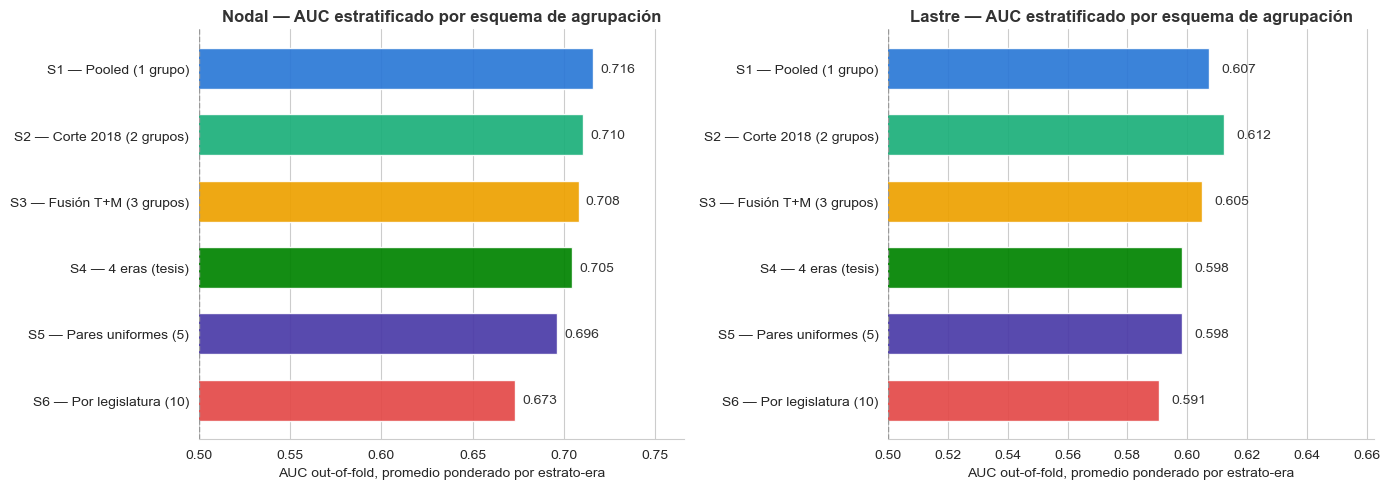

In [12]:
# --- Figura A: AUC ponderado por eras, por esquema (nodal | lastre) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, ttl in [(axes[0], res_nodal, "Nodal"), (axes[1], res_lastre, "Lastre")]:
    vals = res["Pond. eras"].values
    ypos = np.arange(len(SCHEME_ORDER))[::-1]
    bars = ax.barh(ypos, vals, height=0.62, color=SCHEME_COLORS, alpha=0.92)
    for yp, v in zip(ypos, vals):
        ax.text(v + 0.004, yp, f"{v:.3f}", va="center", fontsize=10, color=TXT)
    ax.set_yticks(ypos)
    ax.set_yticklabels([SCHEME_SHORT[s] for s in SCHEME_ORDER], fontsize=10)
    ax.set_xlim(0.5, max(vals) + 0.05)
    ax.axvline(0.5, color="#999999", lw=1, ls="--")
    ax.set_xlabel("AUC out-of-fold, promedio ponderado por estrato-era")
    ax.set_title(f"{ttl} — AUC estratificado por esquema de agrupación",
                 fontsize=12, fontweight="bold", color=TXT)
    ax.grid(axis="y", visible=False)
    sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

**Cómo leer la Figura A.** Barras horizontales = AUC ponderado por estrato-era de cada esquema; la línea discontinua en 0.5 marca el azar. Para **nodal** las barras son casi indistinguibles (todas en la banda ~0.67–0.72): visualmente, la elección de agrupación apenas mueve la discriminación agregada. Para **lastre** las barras están más abajo y aún más planas, confirmando que ese target es poco separable. El mensaje de la figura es la **ausencia de una brecha material** entre la periodización de la tesis (S4) y los esquemas alternativos.


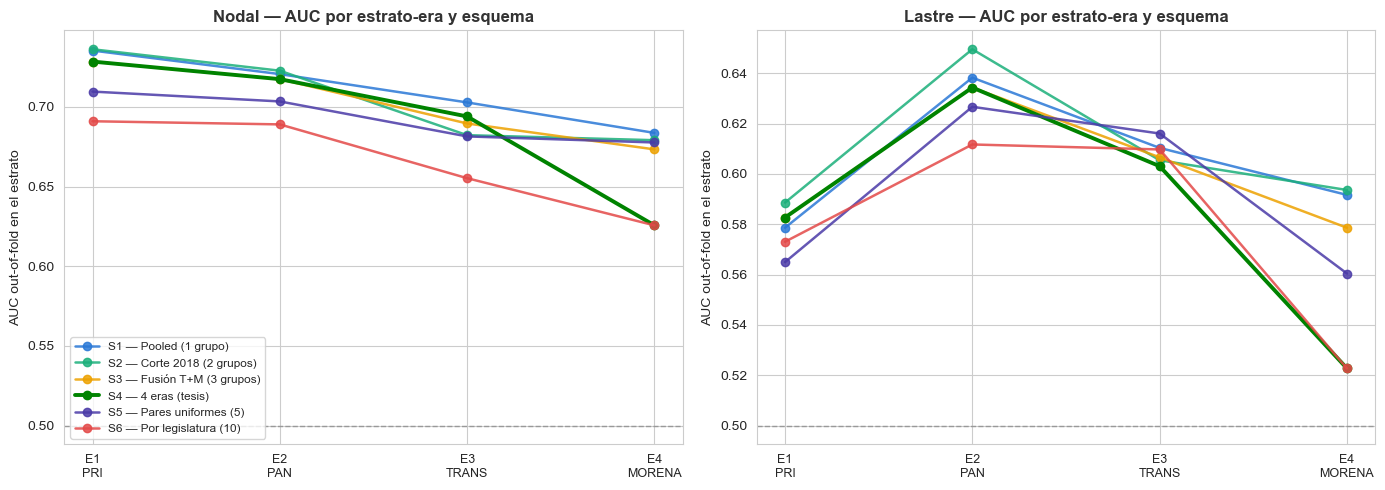

In [13]:
# --- Figura B: AUC por estrato-era, una línea por esquema ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xt = np.arange(len(ERA_ORDER))
for ax, res, ttl in [(axes[0], res_nodal, "Nodal"), (axes[1], res_lastre, "Lastre")]:
    for i, sch in enumerate(SCHEME_ORDER):
        y = [res.loc[SCHEME_SHORT[sch], ERA_LABELS[e].split(" — ")[0]]
             for e in ERA_ORDER]
        lw, alpha = (2.8, 1.0) if sch == "S4_ERAS" else (1.8, 0.85)
        ax.plot(xt, y, marker="o", ms=6, lw=lw, alpha=alpha,
                color=SCHEME_COLORS[i], label=SCHEME_SHORT[sch])
    ax.set_xticks(xt)
    ax.set_xticklabels([e.replace("ERA_", "E").replace("_", "\n") for e in ERA_ORDER],
                       fontsize=9)
    ax.axhline(0.5, color="#999999", lw=1, ls="--")
    ax.set_ylabel("AUC out-of-fold en el estrato")
    ax.set_title(f"{ttl} — AUC por estrato-era y esquema",
                 fontsize=12, fontweight="bold", color=TXT)
axes[0].legend(fontsize=8.5, loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

**Cómo leer la Figura B.** Cada línea es un esquema recorriendo los 4 estratos-era; S4 (tesis) va resaltada en trazo grueso. Donde las líneas se **superponen** (ERA 1–3) la agrupación es irrelevante: todos los esquemas predicen casi igual. Donde se **abren en abanico** (ERA 4) los esquemas de muestra pequeña —S4 y sobre todo S6— caen: es la firma visual de la penalización por n=500 en la última era. La lectura completa de este patrón está en §6.1.


## 6.1 Interpretación — targets binarios

**Panorama.** El AUC ponderado por estrato-era (LR L1+SFM) ordena los esquemas de más grueso a más fino:

| Esquema | Nodal | Lastre |
|---|---:|---:|
| S1 — Pooled | **0.716** | 0.607 |
| S2 — Corte 2018 | 0.710 | **0.612** |
| S3 — Fusión T+M | 0.708 | 0.605 |
| S4 — 4 eras (tesis) | 0.705 | 0.598 |
| S5 — Pares uniformes | 0.696 | 0.598 |
| S6 — Por legislatura | 0.673 | 0.591 |

Cuatro lecturas:

**1. La brecha entre esquemas gruesos y la periodización de la tesis es marginal y se concentra en ERA 4.** La diferencia S1−S4 en nodal es de 0.011 puntos de AUC ponderado — un orden de magnitud por debajo del MDE inter-era (≈0.08) del análisis de potencia de v10 §10.2. Desagregando por estrato, en las eras con n=1,500 los modelos por era rinden prácticamente igual que el pooled (ERA 1: 0.728 vs. 0.735; ERA 2: 0.717 vs. 0.721; ERA 3: 0.694 vs. 0.703). **Toda la ventaja del pooled proviene de ERA 4** (0.684 vs. 0.626): con n=500, el modelo entrenado solo en la LXVI es el más ruidoso de la serie, y los esquemas gruesos lo compensan tomando fuerza prestada de las otras 4,500 observaciones. Este resultado es coherente con el *rolling forward* de v10 (§8.2), donde el modelo entrenado en ERA 3 predice ERA 4 con AUC 0.712 — mejor que el modelo propio de ERA 4 (0.629).

**2. P2 se confirma: más granularidad no ayuda.** El esquema por legislatura (S6) es el peor en todos los estratos y en ambos targets (nodal 0.673, lastre 0.591). La ganancia por homogeneidad no compensa el costo muestral de bajar a n≈500 por modelo. La vista *naive* (tabla anterior) lo corrobora: los AUC por legislatura oscilan de 0.612 (LEG 65) a 0.742 (LEG 57) con desviaciones de hasta ±0.094 — inestabilidad pura.

**3. Las fronteras sustantivas superan a las ventanas arbitrarias.** A granularidad comparable, S4 (4 eras, n=500–1,500) supera a S5 (5 pares uniformes, n=1,000 fijo) en nodal (0.705 vs. 0.696) pese a que S5 tiene grupos en promedio más grandes. Cortar donde cambia la coalición dominante agrupa mejor que cortar cada dos legislaturas.

**4. El corte único en 2018 no es un mal predictor — pero su grupo posterior es internamente heterogéneo.** S2 rinde casi como el pooled (0.710/0.612). Sin embargo, su vista *naive* muestra que el grupo POST_2018 (LXIV–LXVI, n=1,500) alcanza solo 0.689 dentro de grupo, frente a 0.732 del PRE_2018: el corte en 2018 junta el final de la Transición (63–65 comparten composición fragmentada) con la LXVI de mayoría calificada de Morena, dos regímenes que la sección 8 mostrará como distintos en coeficientes.

**Nota sobre el AUC global.** Para S1 el AUC global (0.730) supera al estratificado (0.716): esa diferencia es exactamente el crédito por tasas base entre periodos descrito en §4, y es la razón por la que la comparación honesta entre esquemas debe hacerse dentro de estratos fijos. La columna de robustez (LR L1 completo, sin SFM) replica el ordenamiento en ambos targets.

# 7. Resultados — comisiones temáticas (GLM Poisson)

Mismo protocolo OOF con el GLM Poisson de v10 (`StandardScaler` → `PoissonRegressor(alpha=1.0)`), evaluado con **MAE** (menor = mejor) sobre los mismos estratos fijos. El MAE es directamente comparable entre esquemas porque está en la escala del conteo.

In [14]:
# --- OOF Poisson por esquema + tabla ---
rows = []
for sch in SCHEME_ORDER:
    oof = oof_predict(SCHEMES[sch], "n_comisiones_tematicas", lr_poisson,
                      is_binary=False)
    per_era, w_era = strat_mae(oof, "n_comisiones_tematicas", "era")
    _, w_leg = strat_mae(oof, "n_comisiones_tematicas", "legis_str")
    rows.append({
        "Esquema": SCHEME_SHORT[sch],
        **{ERA_LABELS[e].split(" — ")[0]: per_era.get(e, np.nan) for e in ERA_ORDER},
        "Pond. eras": w_era, "Pond. legis": w_leg,
    })
res_tem = pd.DataFrame(rows).set_index("Esquema")

# Baseline: predecir la media del estrato-era (sin features)
base_rows = {}
for e in ERA_ORDER:
    m = df_enc["era"] == e
    y = df_enc.loc[m, "n_comisiones_tematicas"]
    base_rows[ERA_LABELS[e].split(" — ")[0]] = float(np.abs(y - y.mean()).mean())
base_w = np.average(list(base_rows.values()),
                    weights=[int((df_enc["era"] == e).sum()) for e in ERA_ORDER])
res_tem.loc["Baseline (media por era)"] = {**base_rows, "Pond. eras": base_w,
                                           "Pond. legis": np.nan}

print("TEMÁTICAS — MAE out-of-fold por estrato-era (GLM Poisson; menor = mejor)")
display(res_tem.round(3))

TEMÁTICAS — MAE out-of-fold por estrato-era (GLM Poisson; menor = mejor)


,ERA 1,ERA 2,ERA 3,ERA 4,Pond. eras,Pond. legis
Esquema,,,,,,
S1 — Pooled (1 grupo),0.814,0.795,0.875,0.741,0.819,0.819
S2 — Corte 2018 (2 grupos),0.813,0.784,0.878,0.728,0.815,0.815
S3 — Fusión T+M (3 grupos),0.810,0.788,0.882,0.723,0.816,0.816
S4 — 4 eras (tesis),0.810,0.788,0.885,0.741,0.819,0.819
S5 — Pares uniformes (5),0.809,0.789,0.880,0.737,0.817,0.817
S6 — Por legislatura (10),0.787,0.796,0.891,0.741,0.816,0.816
Baseline (media por era),0.855,0.791,0.895,0.747,0.837,NaN


**Lectura — MAE de comisiones temáticas (GLM Poisson).** El MAE está en la **escala del conteo**: un valor de ~0.82 significa que la predicción se aleja, en promedio, ~0.82 comisiones del valor real (menor = mejor). A diferencia del AUC, es directamente comparable entre esquemas porque comparte escala y estratos, sin distorsión por tasa base. La fila **`Baseline (media por era)`** predice la media del estrato **sin usar features** y fija la vara del valor añadido (§5.4).

*Qué dicen los números.* Todos los esquemas caen en 0.815–0.819, apenas por debajo del baseline (0.837): los features aportan solo ~2–3% de mejora, y la **agrupación es indiferente** para este target. Es la evidencia cuantitativa de que el volumen de comisiones temáticas responde a una lógica distributiva que el perfil biográfico no captura (síntesis en §7.1).


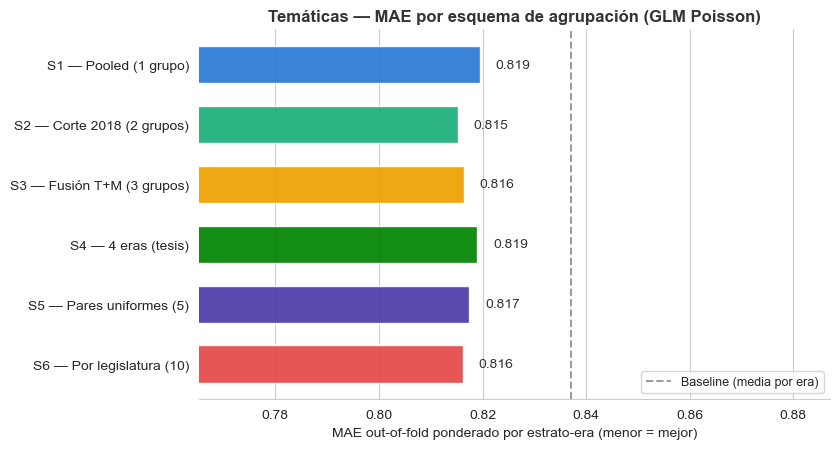

In [15]:
# --- Figura C: MAE ponderado por esquema ---
fig, ax = plt.subplots(figsize=(8.5, 4.6))
vals = res_tem.loc[[SCHEME_SHORT[s] for s in SCHEME_ORDER], "Pond. eras"].values
ypos = np.arange(len(SCHEME_ORDER))[::-1]
ax.barh(ypos, vals, height=0.62, color=SCHEME_COLORS, alpha=0.92)
for yp, v in zip(ypos, vals):
    ax.text(v + 0.003, yp, f"{v:.3f}", va="center", fontsize=10, color=TXT)
ax.axvline(res_tem.loc["Baseline (media por era)", "Pond. eras"],
           color="#999999", lw=1.4, ls="--", label="Baseline (media por era)")
ax.set_yticks(ypos)
ax.set_yticklabels([SCHEME_SHORT[s] for s in SCHEME_ORDER], fontsize=10)
ax.set_xlabel("MAE out-of-fold ponderado por estrato-era (menor = mejor)")
ax.set_title("Temáticas — MAE por esquema de agrupación (GLM Poisson)",
             fontsize=12, fontweight="bold", color=TXT)
ax.set_xlim(min(vals) - 0.05, max(max(vals), base_w) + 0.05)
ax.legend(fontsize=9, loc="lower right", frameon=True)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

**Cómo leer la Figura C.** Barras = MAE ponderado de cada esquema; la línea discontinua es el *baseline* de "predecir la media de la era". Todas las barras se agolpan apenas a la izquierda del baseline y entre sí: mejora **marginal y plana**. La figura hace visible de un vistazo la conclusión de §7.1 — para las temáticas, ningún esquema de agrupación mueve la aguja.


## 7.1 Interpretación — temáticas

El MAE ponderado es **plano entre esquemas**: de 0.815 (S2) a 0.819 (S1 y S4), una banda de 0.004 comisiones — ruido. Ningún esquema mejora el baseline de "predecir la media de la era" (0.837) en más de 2.7%. La elección de agrupación es **irrelevante** para este target, lo que refuerza el hallazgo H3 de la tesis: el volumen de comisiones temáticas es una asignación distributiva/administrativa que el perfil biográfico no captura, se agrupe como se agrupe. Este target no discrimina entre periodizaciones y no aporta evidencia ni a favor ni en contra de las 4 eras.

# 8. Heterogeneidad de coeficientes entre legislaturas

Si la periodización en 4 eras es sustantiva, los vectores de coeficientes de una LR L1 ajustada **por legislatura** deben parecerse más *dentro* de una era que *entre* eras (estructura de bloques). Se ajusta `lr_binary` (L1 completo, sin SFM, para que los 61 coeficientes sean comparables posición a posición) sobre `nodal_bin` en cada legislatura, excluyendo `legislatura_num` del espacio de features (constante dentro de cada grupo), y se calcula la **similitud coseno** entre los 10 vectores.

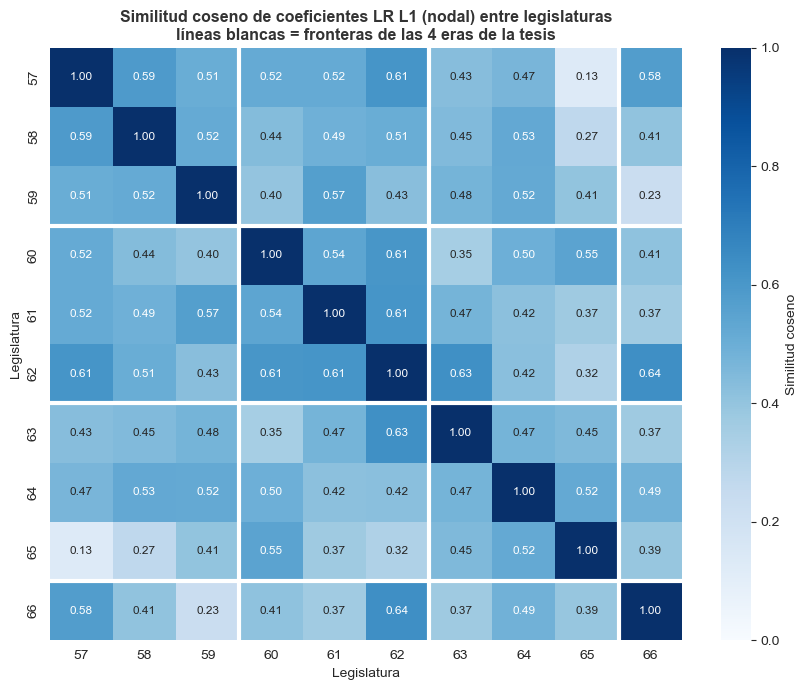

In [16]:
# --- Matriz de similitud coseno entre legislaturas (nodal) ---
FEATS_NOLEG = [f for f in FEAT_COLS if f != "legislatura_num"]
coefs = {}
for l in LEGIS:
    m = df_enc["legislatura_num"] == l
    X = df_enc.loc[m, FEATS_NOLEG].astype(float)
    y = df_enc.loc[m, "nodal_bin"].astype(float)
    pipe = Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(**_L1_PARAMS))]).fit(X, y)
    coefs[l] = pipe.named_steps["lr"].coef_.ravel()
C = np.vstack([coefs[l] for l in LEGIS])
S = cosine_similarity(C)

fig, ax = plt.subplots(figsize=(8.6, 7))
sns.heatmap(S, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=LEGIS, yticklabels=LEGIS, ax=ax,
            annot_kws={"fontsize": 8.5}, cbar_kws={"label": "Similitud coseno"})
# Fronteras de era (después de la 59, la 62 y la 65)
for b in [3, 6, 9]:
    ax.axhline(b, color="white", lw=3)
    ax.axvline(b, color="white", lw=3)
ax.set_title("Similitud coseno de coeficientes LR L1 (nodal) entre legislaturas\n"
             "líneas blancas = fronteras de las 4 eras de la tesis",
             fontsize=11.5, fontweight="bold", color=TXT)
ax.set_xlabel("Legislatura"); ax.set_ylabel("Legislatura")
plt.tight_layout()
plt.show()

**Lectura — heatmap de similitud coseno de coeficientes.** Cada celda es la similitud coseno (0–1) entre los vectores de 61 coeficientes de la LR L1 ajustada en dos legislaturas: **1 = misma lógica de asignación**, 0 = ortogonal. Las líneas blancas marcan las fronteras de las 4 eras. Se observan **bloques más oscuros en la diagonal dentro de cada era** (legislaturas de una misma era comparten estructura de coeficientes), mientras que la **LXVI (66)** es marcadamente disímil de las 63–65 — la razón de que fusionar Transición y Morena destruya señal.

*Relevancia para el análisis.* Este diagnóstico responde una pregunta que el AUC **no puede** contestar: no *cuánto* predice cada esquema, sino **si sus fronteras caen donde de verdad cambia el mecanismo** de asignación. Opera sobre los **coeficientes** (la lógica del modelo), no sobre las predicciones (su desempeño); por eso es el instrumento que valida la periodización por su contenido interpretativo (§5.5).


In [17]:
# --- Similitud media dentro vs. entre grupos, por esquema ---
def block_similarity(mapping):
    "Similitud coseno media dentro de grupos vs. entre grupos (pares i<j)."
    within, between = [], []
    for i, li in enumerate(LEGIS):
        for j, lj in enumerate(LEGIS):
            if j <= i:
                continue
            (within if mapping[li] == mapping[lj] else between).append(S[i, j])
    w = float(np.mean(within)) if within else np.nan
    b = float(np.mean(between)) if between else np.nan
    return w, b

rows = []
for sch in SCHEME_ORDER:
    w, b = block_similarity(SCHEMES[sch])
    rows.append({"Esquema": SCHEME_SHORT[sch],
                 "Sim. dentro de grupo": w, "Sim. entre grupos": b,
                 "Δ (dentro − entre)": (w - b) if not (np.isnan(w) or np.isnan(b))
                                        else np.nan})
df_block = pd.DataFrame(rows).set_index("Esquema")
print("Cohesión de coeficientes por esquema (mayor Δ = la partición agrupa")
print("legislaturas con lógica de asignación más parecida):")
display(df_block.round(3))

Cohesión de coeficientes por esquema (mayor Δ = la partición agrupa
legislaturas con lógica de asignación más parecida):


,Sim. dentro de grupo,Sim. entre grupos,Δ (dentro − entre)
Esquema,,,
S1 — Pooled (1 grupo),0.464,NaN,NaN
S2 — Corte 2018 (2 grupos),0.502,0.421,0.081
S3 — Fusión T+M (3 grupos),0.506,0.449,0.057
S4 — 4 eras (tesis),0.535,0.446,0.089
S5 — Pares uniformes (5),0.493,0.460,0.033
S6 — Por legislatura (10),NaN,0.464,NaN


**Lectura — cohesión de coeficientes (Δ = dentro − entre).** Para cada esquema se promedia la similitud coseno **dentro** de sus grupos y **entre** grupos; **Δ** es su diferencia. Un Δ grande significa que la partición traza sus fronteras justo donde la lógica de coeficientes cambia (bloques internamente parecidos, contraste alto hacia afuera). S1 y S6 muestran `NaN` porque, por construcción, no tienen pares entre-grupos (un solo grupo) o dentro-de-grupo (grupos de una legislatura), respectivamente.

*Relevancia para el análisis.* Δ es una métrica de **validez estructural**, complementaria al AUC: un esquema puede predecir bien y aun así cortar mal (el caso de S2). La periodización de la tesis (S4) alcanza el Δ máximo (0.089), lo que la §8.1 interpreta como que sus fronteras son las que mejor coinciden con los cambios reales del mecanismo de asignación.


## 8.1 Interpretación — heterogeneidad de coeficientes

Este análisis pregunta algo distinto al AUC: no *cuánto* predice cada esquema, sino **si sus fronteras cortan donde de verdad cambia la lógica de asignación**. El indicador Δ (similitud media dentro de grupo − entre grupos) mide la calidad estructural de cada partición:

| Esquema | Sim. dentro | Sim. entre | Δ |
|---|---:|---:|---:|
| S4 — 4 eras (tesis) | **0.535** | 0.446 | **0.089** |
| S2 — Corte 2018 | 0.502 | 0.421 | 0.081 |
| S3 — Fusión T+M | 0.506 | 0.449 | 0.057 |
| S5 — Pares uniformes | 0.493 | 0.460 | 0.033 |

**La periodización de la tesis es la que mejor agrupa.** S4 alcanza a la vez la mayor cohesión interna (0.535) y el mayor contraste dentro/entre (Δ=0.089). Los otros resultados son informativos por qué pierden:

- **S3 (fusionar Transición y Morena) destruye casi 40% del contraste** (Δ cae de 0.089 a 0.057): la LXVI no se parece, en coeficientes, a las legislaturas 63–65. Separar ERA 4 de ERA 3 no es ornamental — es donde más señal estructural hay.
- **S2 (corte 2018) retiene la mayor parte del contraste** (Δ=0.081) porque 2018 sí es una frontera real — pero su cohesión interna (0.502) es menor que la de S4 porque mete en un mismo grupo las siete legislaturas 57–63, mezclando los regímenes PRI y PAN que el heatmap muestra como bloques distintos.
- **S5 (pares uniformes) apenas supera al azar estructural** (Δ=0.033): las ventanas ciegas a la política parten los bloques reales por la mitad.

La similitud media global entre los 10 vectores de coeficientes es 0.464 — lejos de 1.0: la lógica de asignación nodal **no** es estable a lo largo de las diez legislaturas, y por eso el modelo único (S1), aunque predice bien en promedio, estima un mecanismo que no corresponde a ninguna era en particular.

# 9. Conclusiones

## 9.1 Veredicto sobre las predicciones de §1.4

**P1 (contra agrupaciones más gruesas) — se cumple en ERA 1–3, con un matiz en ERA 4.** En las eras con n=1,500, los modelos por era rinden estadísticamente igual que el pooled y que el corte en 2018 (diferencias ≤0.011 de AUC, muy por debajo del MDE≈0.08). En ERA 4 (n=500) los esquemas gruesos ganan claramente (0.684 vs. 0.626 nodal) por fuerza prestada. Esto **matiza pero no refuta** la periodización: la limitación muestral de ERA 4 ya estaba reconocida en v10 §10.2, y el remedio natural es más datos (la LXVII en 2027) o *partial pooling* jerárquico — no abandonar la frontera, que la sección 7 muestra como la más real de todas.

**P2 (contra agrupaciones más finas) — se cumple sin matices.** El esquema por legislatura es el peor en ambos targets y en todos los estratos. Las eras no están mezclando legislaturas heterogéneas en un grado que justifique partirlas.

## 9.2 ¿Por qué funciona la división en 4 eras? — síntesis con la evidencia de este cuaderno

La respuesta que emerge es más precisa que "porque predice mejor":

1. **Su costo predictivo es despreciable** (−0.011 AUC nodal ponderado frente al mejor esquema; −0.005 frente al corte 2018) y está localizado en la era con una sola legislatura.
2. **Es la partición estructuralmente correcta**: maximiza la cohesión de coeficientes dentro de grupo (Δ=0.089, la mayor de todos los esquemas) — sus fronteras coinciden con los cambios reales del mecanismo de asignación, cosa que ni las ventanas uniformes (Δ=0.033) ni la fusión Transición+Morena (Δ=0.057) logran.
3. **Es la única que sostiene el aparato interpretativo de la tesis**: los hallazgos H4 (ruptura en la transición), H5 (legislativización del perfil en Morena) y H7 (cierre de la brecha de género en ERA 4) requieren un vector de coeficientes por era. Con un corte único en 2018, H4 y H5 serían inobservables por construcción; con el pooled, los coeficientes describirían un promedio de regímenes que no existió en ningún periodo (§8.1).

En suma: **la división en 4 eras no se justifica por una ventaja de AUC —que no la tiene ni la necesita—, sino porque compra la validez comparativa e interpretativa de la tesis a un precio predictivo estadísticamente indistinguible de cero.** La alternativa de dos eras con corte en 2018 es un esquema de robustez razonable (predice igual de bien y su frontera es real), pero es demasiado gruesa para las preguntas de la tesis: funde PRI con PAN y el final de la Transición con Morena, exactamente las distinciones que los hallazgos comparativos explotan.

## 9.3 Recomendaciones

- **Mantener las 4 eras como especificación principal**; citar este cuaderno como prueba de robustez de la periodización.
- **Reportar el pooled y el corte 2018 como análisis de sensibilidad**: muestran que las conclusiones predictivas (nodal moderadamente predecible, lastre opaco, temáticas impredecibles) no dependen de la partición.
- **Para ERA 4, considerar *partial pooling*** (modelo jerárquico con eras como niveles — extensión natural de la capa bayesiana de v7/v10) mientras no exista la LXVII: la evidencia de este cuaderno cuantifica exactamente cuánto AUC deja sobre la mesa el no-pooling en la era corta (≈0.06).
- **No invertir en re-agrupar para temáticas**: ningún esquema mueve el MAE.